SSE: [0. 0.]
Accuracy: 0.0


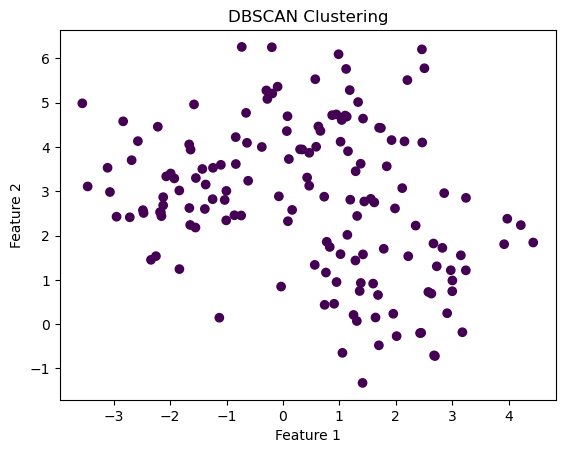

In [4]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Generate sample data
X, y = make_blobs(n_samples=150, centers=3, n_features=2, random_state=0)

# Perform DBSCAN clustering
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Calculate the Sum of Squared Errors (SSE)
sse = np.mean((X - X[labels == -1])**2, axis=0)
print("SSE:", sse)

# Calculate the accuracy
y_pred = labels
y_true = np.zeros_like(labels)
y_true[labels != -1] = 1
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Create a figure and axis
fig, ax = plt.subplots()

# Plot the original data
ax.scatter(X[:, 0], X[:, 1], c=labels)

# Set the title and labels
ax.set_title('DBSCAN Clustering')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

# Show the plot
plt.show()

In [6]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # we only take the first two features.

# Perform DBSCAN clustering
eps_values = np.arange(0.1, 1.0, 0.1)
sse_values = []
accuracy_values = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10).fit(X)
    labels = db.labels_
    sse = np.mean((X - X[labels == -1])**2, axis=0)
    sse_values.append(sse)
    y_pred = labels
    y_true = np.zeros_like(labels)
    y_true[labels != -1] = 1
    accuracy = accuracy_score(y_true, y_pred)
    accuracy_values.append(accuracy)

# Create a figure and axis
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Plot the SSE
ax[0].plot(eps_values, sse_values)
ax[0].set_title('Sum of Squared Errors (SSE)')
ax[0].set_xlabel('Epsilon')
ax[0].set_ylabel('SSE')

# Plot the accuracy
ax[1].plot(eps_values, accuracy_values)
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epsilon')
ax[1].set_ylabel('Accuracy')

# Show the plot
plt.show()

ValueError: operands could not be broadcast together with shapes (150,2) (87,2) 

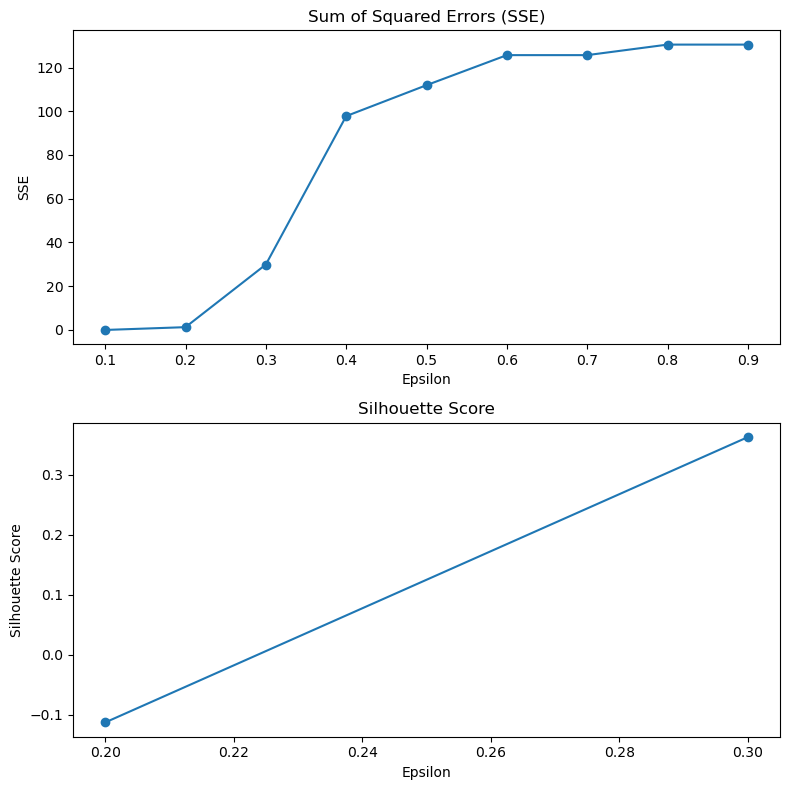

In [7]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # only the first two features

# Set up DBSCAN parameters and evaluation metrics
eps_values = np.arange(0.1, 1.0, 0.1)
sse_values = []
silhouette_scores = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10).fit(X)
    labels = db.labels_
    
    # Calculate SSE for clusters (ignoring noise points with label -1)
    unique_labels = set(labels) - {-1}
    sse = 0
    for label in unique_labels:
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        sse += np.sum((cluster_points - centroid) ** 2)
    sse_values.append(sse)
    
    # Calculate Silhouette Score (only if we have more than 1 cluster)
    if len(unique_labels) > 1:
        silhouette = silhouette_score(X, labels, metric="euclidean")
    else:
        silhouette = np.nan
    silhouette_scores.append(silhouette)

# Create a figure and axis
fig, ax = plt.subplots(2, 1, figsize=(8, 8))

# Plot the SSE
ax[0].plot(eps_values, sse_values, marker='o')
ax[0].set_title('Sum of Squared Errors (SSE)')
ax[0].set_xlabel('Epsilon')
ax[0].set_ylabel('SSE')

# Plot the Silhouette Score
ax[1].plot(eps_values, silhouette_scores, marker='o')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Epsilon')
ax[1].set_ylabel('Silhouette Score')

# Show the plot
plt.tight_layout()
plt.show()
